## Problem 8.3 - Regression with Kernel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

In [29]:
def f_1(x):
    return np.sin(4 * np.pi * x)

In [30]:
def f_2(x): 
    x = np.array(x)
    return 4 * np.maximum(0, x - 1/2) - 1

In [31]:
def f_3(x):
    x = np.array(x)
    return np.piecewise(x,
        [ (0 <= x) & (x <= 1/4),
          (1/4 < x) & (x <= 1/2),
          (1/2 < x) & (x <= 3/4),
          (3/4 < x) & (x <= 1)],
        [lambda x: -1 + 8 * x,
         lambda x: 1 - 8 * (x - 1/4),
         lambda x: -1 + 8 * (x - 1/2),
         lambda x: 1 - 8 * (x - 3/4)]
    )

In [46]:
def f_4(x):
    return np.piecewise(x,
        [ (0 <= x) & (x <= 1/4),
          (1/4 < x) & (x <= 1/2),
          (1/2 < x) & (x <= 3/4),
          (3/4 < x) & (x <= 1)],
        [lambda x:  1,
         lambda x: -1,
         lambda x: 1,
         lambda x: -1])
        

In [54]:
# define the setting
n = [100, 200, 500]
sd = [0.05, 0.1, 0.2, 0.5]
functions = {"f1": f_1, "f2": f_2, "f3":f_3, "f4": f_4}


#### Explanation of the param_grid we use:

- alpha: regularization parameter  
    large alpha -> strong regularization -> smoother approximation -> less likely to overfit  
    small alpha -> weak regularization -> fits data more closely -> overfitting likely  

- gamma: kernel width for RBF  
    large gamma -> narrow kernel -> model reacts strongly to nearby points -> overfitting  
    small gamma -> wide kernel -> smoother approximation -> may underfit  
    -> controls smoothness of the approximating function for RBF kernels  

- degree: polynomial degree  
    large degree -> higher-oder polynomials -> more flexible, but also more potential to overfit  
    small degree -> simpler polynomial approximation  

In [55]:
param_grid = {
        "alpha": [1, 1e-1, 1e-2, 1e-3],
        "gamma": np.logspace(-2, 2, 5),
        'degree': [2, 3, 5],
    }

In [59]:
def get_approximation(ax, function,  n_val, sd_val, kernel_type = 'rbf'):
    x = np.random.uniform(0, 1, size = n_val)
    x = np.sort(x)
    y_true = function(x)
    y = y_true + np.random.normal(0, sd_val, size = n_val)

    kr = GridSearchCV(KernelRidge(kernel = kernel_type), param_grid = param_grid)
    kr.fit(x.reshape(-1, 1), y)
    best_model = kr.best_estimator_
    
    x_plot = np.linspace(0, 1, 500)
    y_pred = best_model.predict(x_plot.reshape(-1, 1))

    ax.scatter(x, y, color='pink', alpha=0.5, label = 'Noisy observations')
    ax.plot(x_plot, function(x_plot), color = 'hotpink', label = 'Ground truth', linewidth = 2)
    ax.plot(x_plot, y_pred, color = 'plum', label = 'Approximation', linewidth = 2)
    ax.set_title(f'{kernel_type.upper()} | n={n_val}, sd={sd_val}\nBest params: {kr.best_params_}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True)




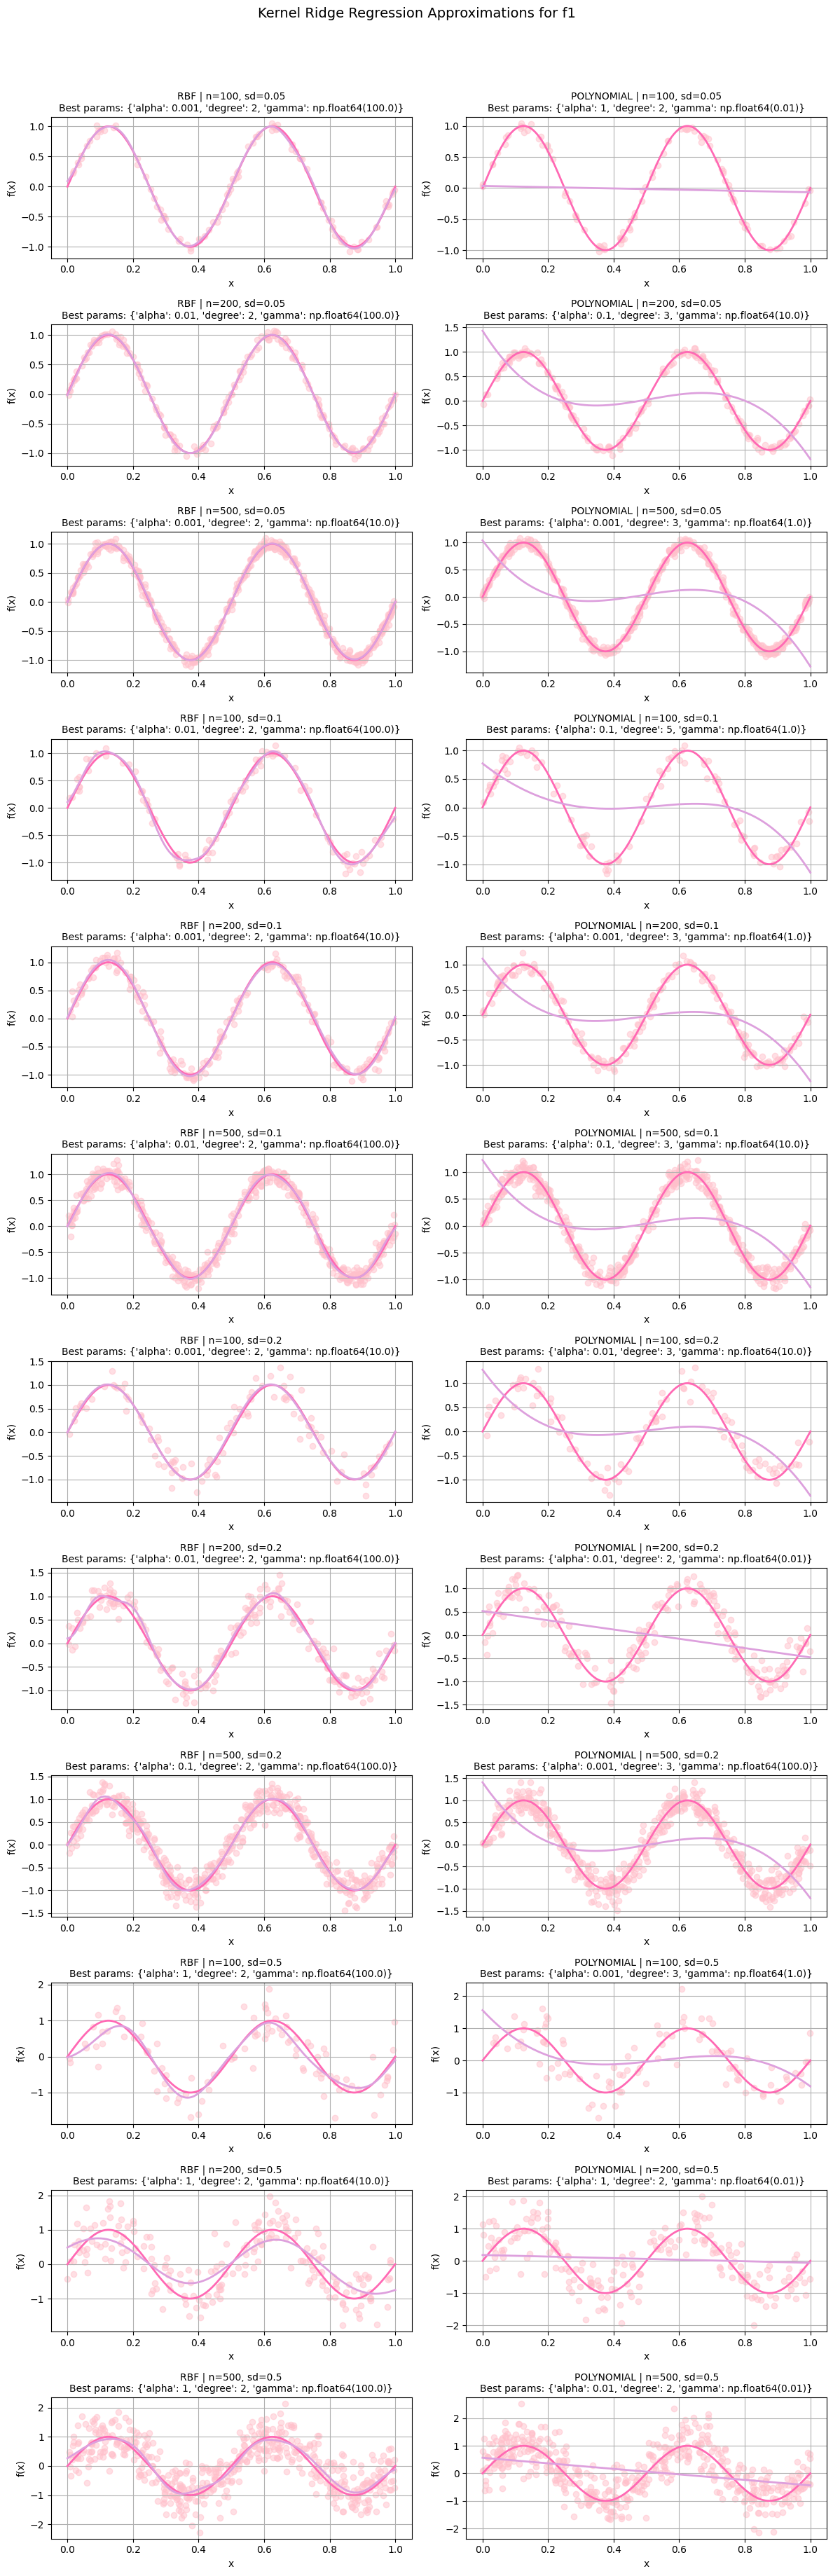

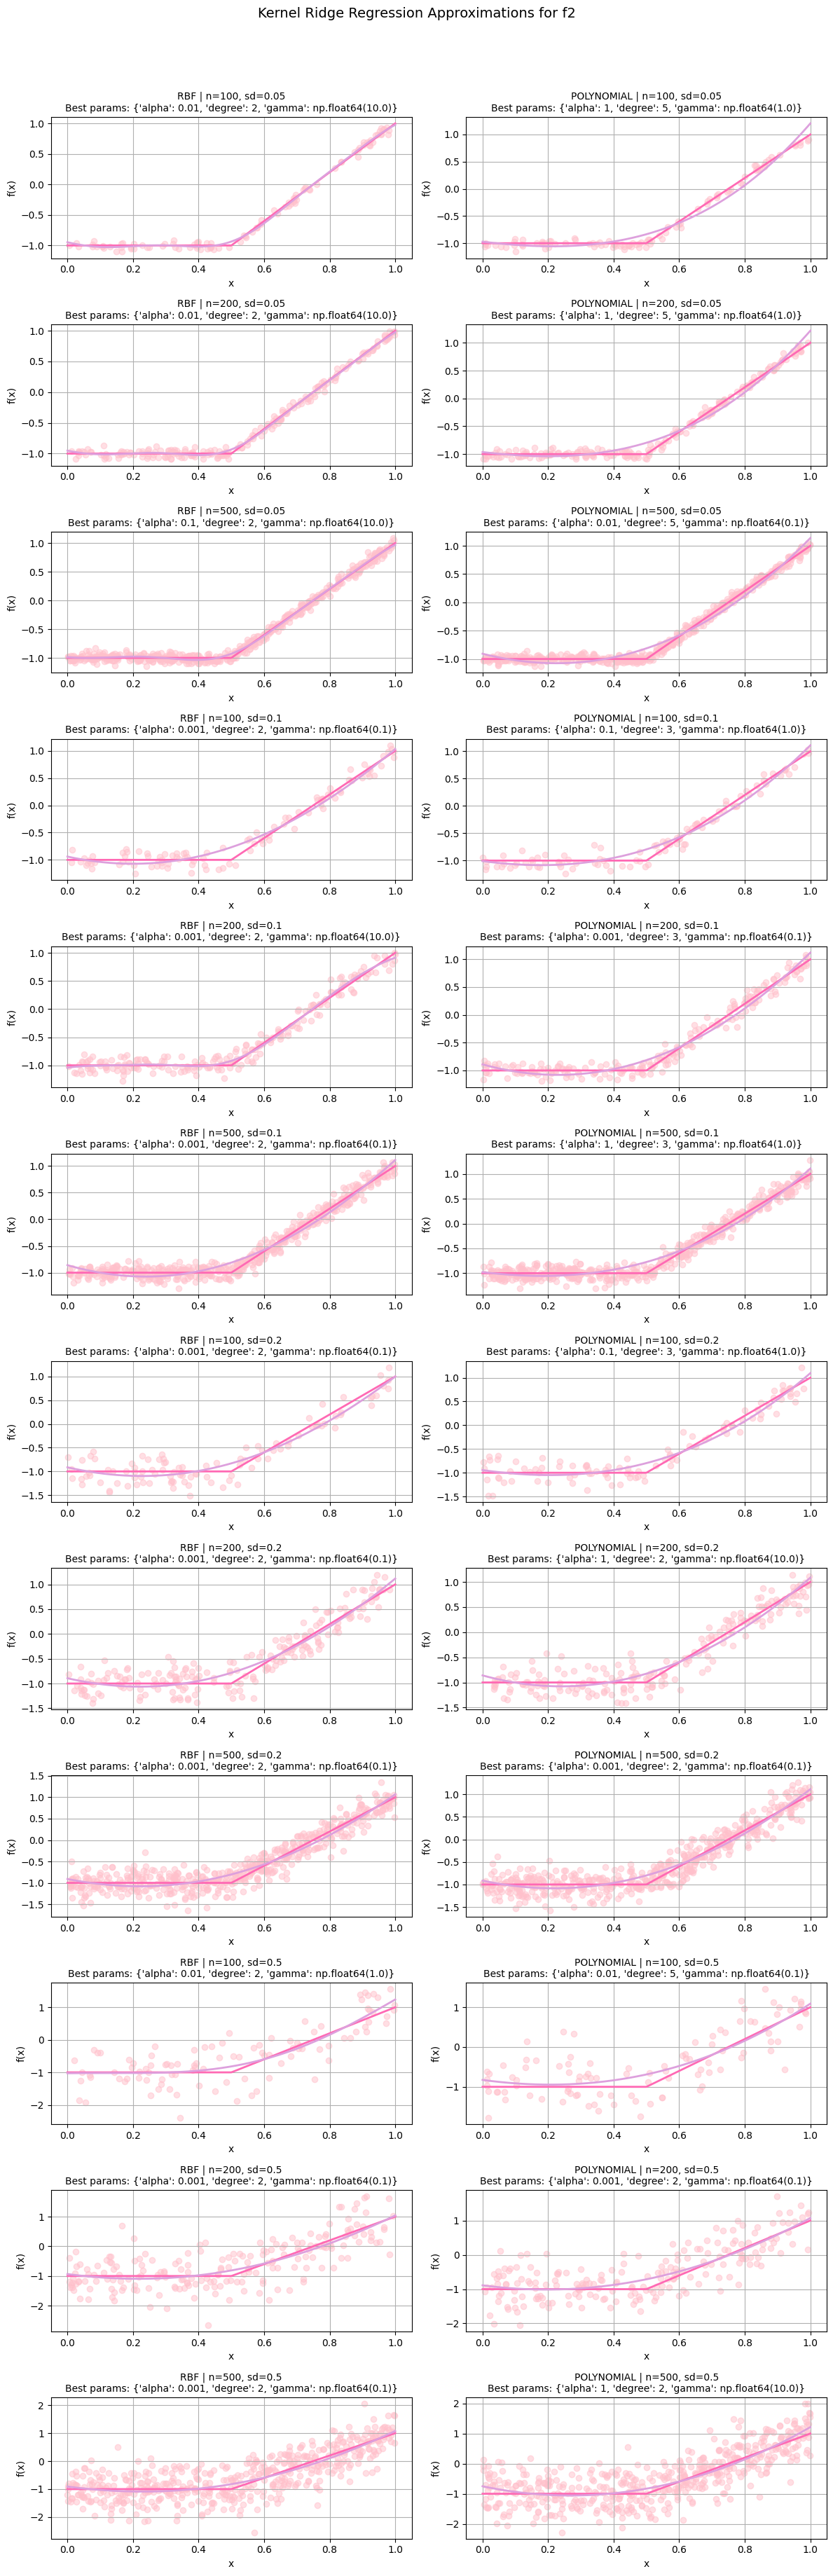

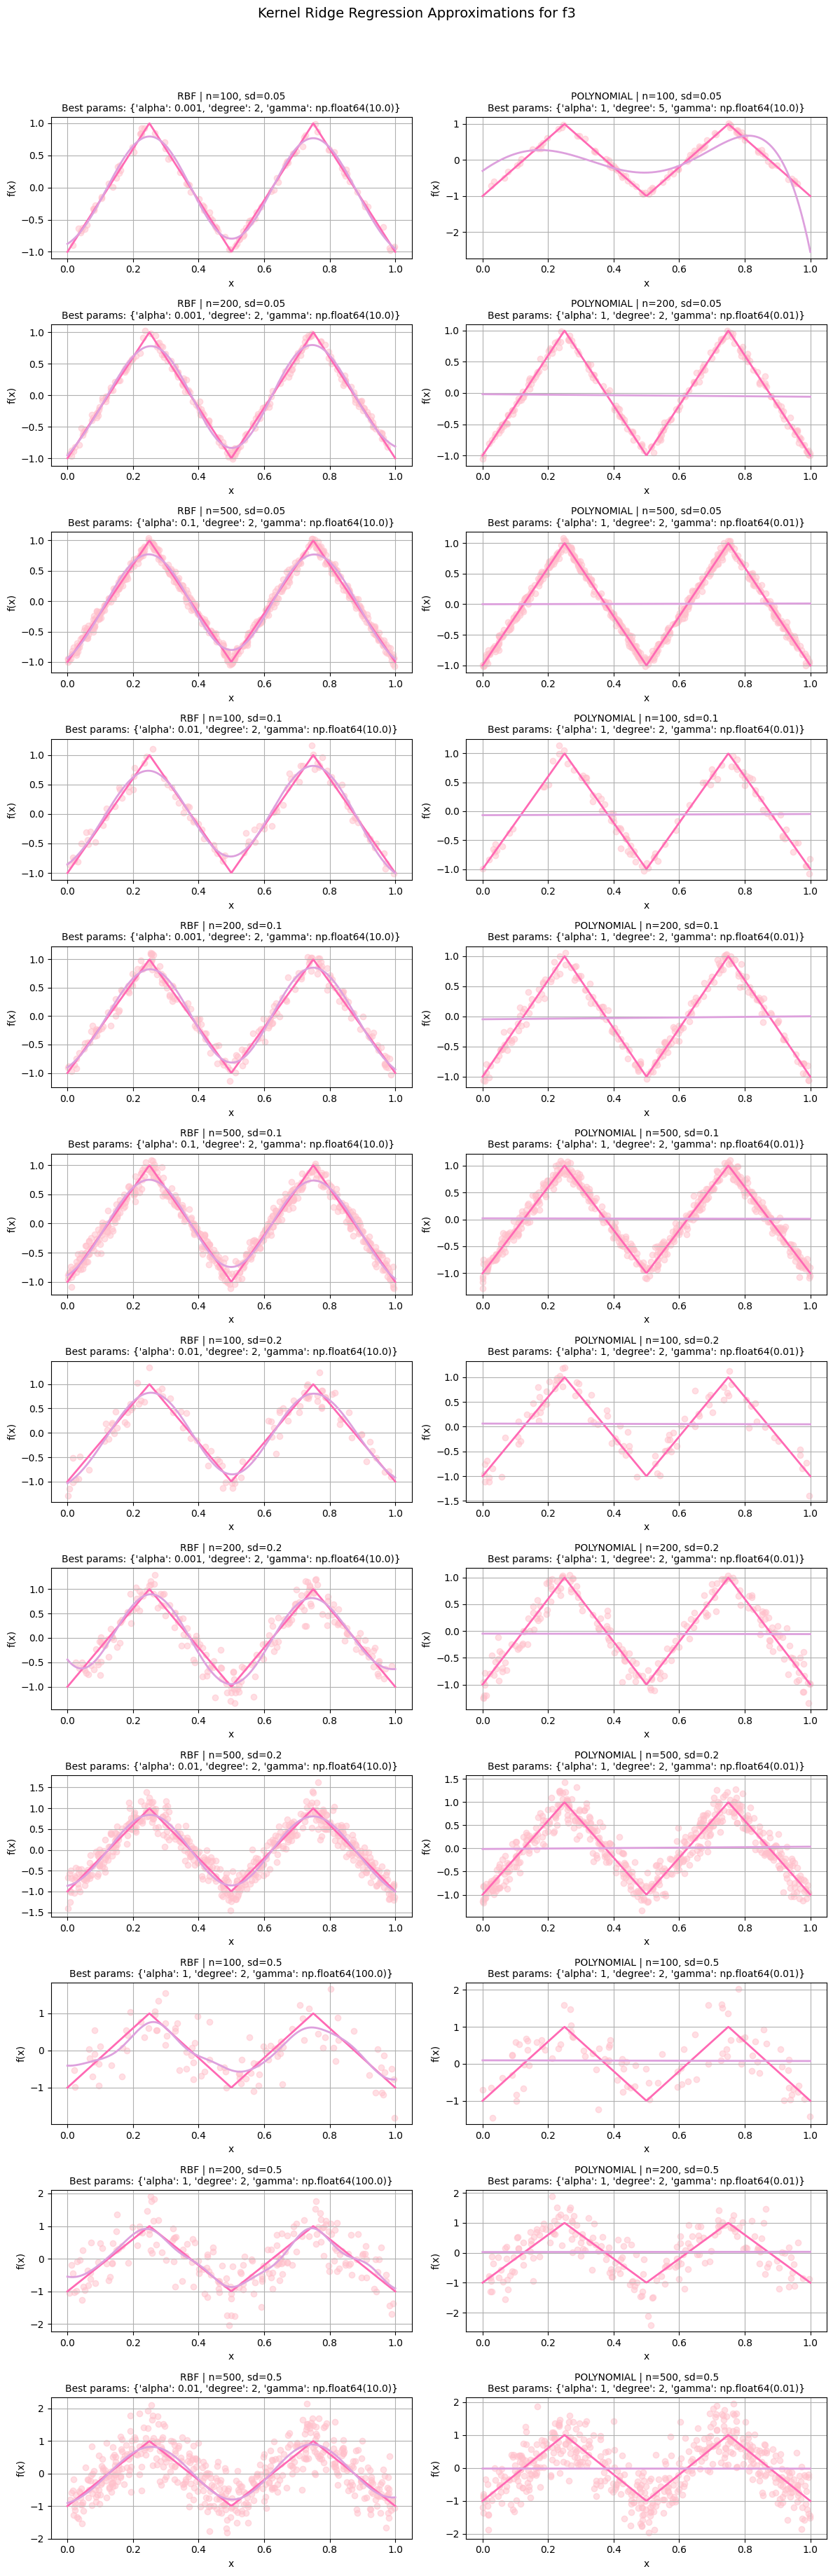

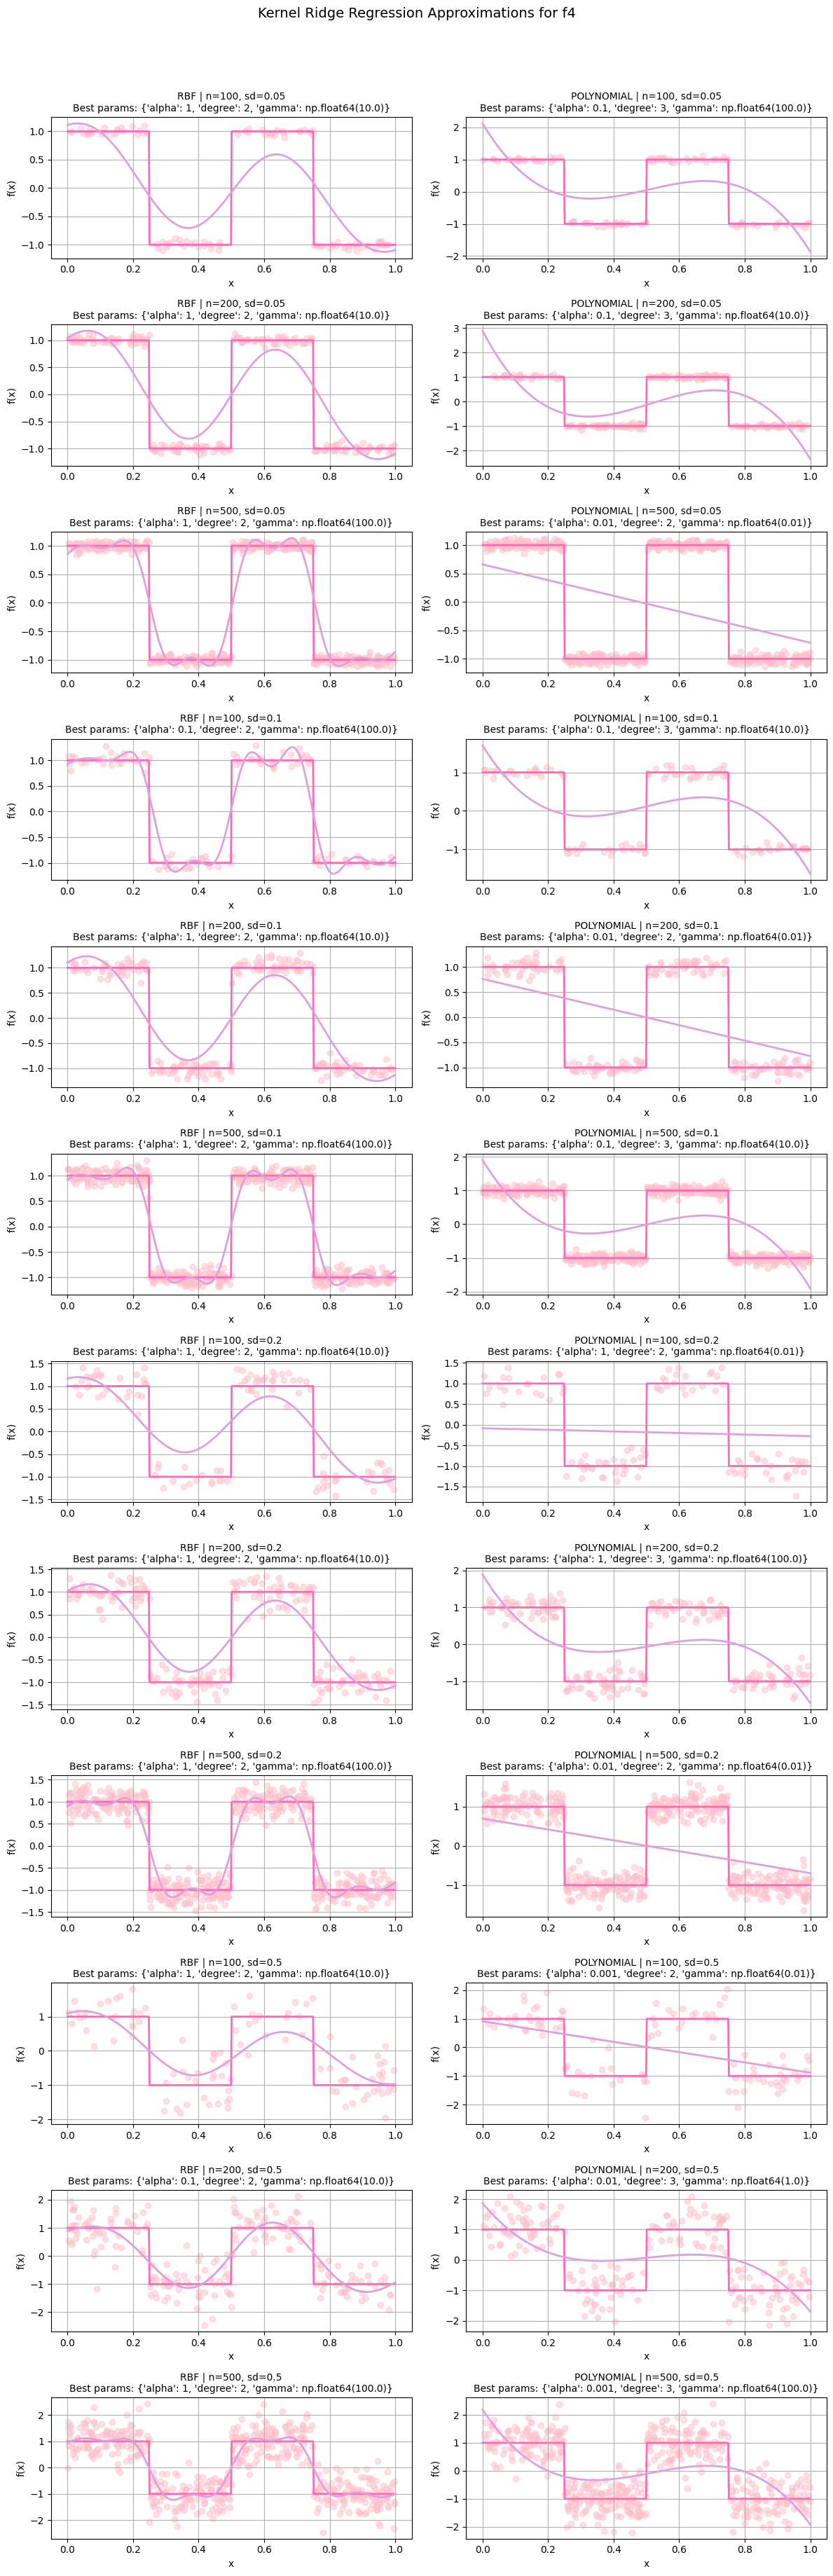

In [60]:
for func_name, func in functions.items():
    fig, axes = plt.subplots(len(sd)*len(n), 2, figsize=(12, len(sd)*len(n)*3))
    fig.suptitle(f'Kernel Ridge Regression Approximations for {func_name}', fontsize=14, y=1.02)

    # Flatten axes for easier iteration
    axes = axes.reshape(len(sd)*len(n), 2)

    for i, sd_val in enumerate(sd):
        for j, n_val in enumerate(n):
            row = i*len(n) + j
            get_approximation(axes[row,0], func, n_val, sd_val, kernel_type='rbf')
            get_approximation(axes[row,1], func, n_val, sd_val, kernel_type='polynomial')

    plt.tight_layout()
    plt.show()